# LumenY 9 — Episode Low Detector

**Setup**: Price is below both MA50 and MA200 (below-both episode).

**Target**: Is the current bar's low the lowest low of the entire episode?

If yes → enter long, ride the full swing (~70-120p) back up through both MAs.

**Features**: features_10 (geometric + MA context)

**Model**: LightGBM binary classifier

In [66]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss

FEATURES_10_DIR = Path('../backend/data/features_10')
PROCESSED_DIR   = Path('../backend/data/processed')
MODELS_DIR      = Path('../backend/models_10/ma_cross')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = '2024-06-30'
SPREAD_PIPS = 1.5

PAIRS = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
]
PIP_SIZE = {
    'EURUSD':0.0001,'GBPUSD':0.0001,'USDCHF':0.0001,'AUDUSD':0.0001,
    'USDCAD':0.0001,'NZDUSD':0.0001,'EURGBP':0.0001,'EURAUD':0.0001,'AUDNZD':0.0001,
    'USDJPY':0.01,'EURJPY':0.01,'GBPJPY':0.01,'AUDJPY':0.01,'CADJPY':0.01,'CHFJPY':0.01,
}

print('Ready.')
print('Target: is this bar the episode low? (lowest low of the entire below-both episode)')
print(f'Training cutoff: {TRAIN_END}')


Ready.
Target: is this bar the episode low? (lowest low of the entire below-both episode)
Training cutoff: 2024-06-30


## 1. Compute Episode Low / High Labels

For each below-both episode: bar with lowest low = label_long=1.
For each above-both episode: bar with highest high = label_short=1.

In [67]:
print('Computing episode low/high labels...')
label_parts = []

for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close', 'high', 'low']]
    ohlc.index = pd.to_datetime(ohlc.index)

    c     = ohlc['close'].values
    hi    = ohlc['high'].values
    lo    = ohlc['low'].values
    ma50  = pd.Series(c).rolling(50).mean().values
    ma200 = pd.Series(c).rolling(200).mean().values
    n     = len(c)

    both_below = (c < ma50) & (c < ma200)
    both_above = (c > ma50) & (c > ma200)
    label_long  = np.full(n, np.nan)
    label_short = np.full(n, np.nan)

    # LONG: episode low
    i = 0
    while i < n:
        if np.isnan(ma50[i]) or np.isnan(ma200[i]) or not both_below[i]:
            i += 1; continue
        ep_start = i
        while i < n:
            if np.isnan(ma50[i]) or np.isnan(ma200[i]): i += 1; break
            if both_above[i]: break
            i += 1
        ep_end = i
        ep_lows = lo[ep_start:ep_end]
        if len(ep_lows) == 0: continue
        min_idx = ep_start + int(np.argmin(ep_lows))
        for j in range(ep_start, ep_end):
            if np.isnan(ma50[j]) or np.isnan(ma200[j]): continue
            label_long[j] = 1.0 if j == min_idx else 0.0

    # SHORT: episode high
    i = 0
    while i < n:
        if np.isnan(ma50[i]) or np.isnan(ma200[i]) or not both_above[i]:
            i += 1; continue
        ep_start = i
        while i < n:
            if np.isnan(ma50[i]) or np.isnan(ma200[i]): i += 1; break
            if both_below[i]: break
            i += 1
        ep_end = i
        ep_highs = hi[ep_start:ep_end]
        if len(ep_highs) == 0: continue
        max_idx = ep_start + int(np.argmax(ep_highs))
        for j in range(ep_start, ep_end):
            if np.isnan(ma50[j]) or np.isnan(ma200[j]): continue
            label_short[j] = 1.0 if j == max_idx else 0.0

    tmp = pd.DataFrame({'label_long': label_long, 'label_short': label_short, 'pair': pair}, index=ohlc.index)
    label_parts.append(tmp)

df_labels = pd.concat(label_parts).sort_index()
long_pop  = df_labels['label_long'].dropna()
short_pop = df_labels['label_short'].dropna()
print(f'Long  labeled: {len(long_pop):,}  hit rate={long_pop.mean():.4f}  (1 per {1/long_pop.mean():.0f} bars)')
print(f'Short labeled: {len(short_pop):,}  hit rate={short_pop.mean():.4f}  (1 per {1/short_pop.mean():.0f} bars)')


Computing episode low/high labels...
Long  labeled: 720,597  hit rate=0.0195  (1 per 51 bars)
Short labeled: 751,145  hit rate=0.0187  (1 per 53 bars)


## 2. Build Dataset

In [68]:
print('Loading features_10...')
dfs = []
for pair in PAIRS:
    feat = pd.read_parquet(FEATURES_10_DIR / f'{pair}_features.parquet')
    feat = feat.drop(columns=[c for c in feat.columns if c.startswith('label_')], errors='ignore')
    dfs.append(feat)

df_feat = pd.concat(dfs).sort_index()
print(f'features_10: {df_feat.shape}')

df_f   = df_feat.reset_index()
df_l   = df_labels.reset_index()
ts_col = df_f.columns[0]
df     = pd.merge(df_f, df_l, on=[ts_col, 'pair'], how='inner')
df     = df.set_index(ts_col).sort_index()
del df_feat, df_f, df_l; gc.collect()

drop_cols    = ['label_long', 'label_short', 'pair', 'both_below', 'both_above']
feature_cols = [c for c in df.columns if c not in drop_cols]
print(f'Feature cols: {len(feature_cols)}')

df_sig_long  = df[(df['both_below'] == 1) & df['label_long'].notna()].copy()
df_sig_short = df[(df['both_above'] == 1) & df['label_short'].notna()].copy()
print(f'Long  episode bars: {len(df_sig_long):,}   pos_rate={df_sig_long["label_long"].mean():.4f}')
print(f'Short episode bars: {len(df_sig_short):,}  pos_rate={df_sig_short["label_short"].mean():.4f}')


Loading features_10...
features_10: (1474755, 86)
Feature cols: 83
Long  episode bars: 527,048   pos_rate=0.0245
Short episode bars: 560,099  pos_rate=0.0234


## 3. Train LightGBM

In [69]:
def train_ep_model(X_tr, y_tr, label):
    pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'n_estimators': 3000, 'learning_rate': 0.02, 'num_leaves': 64,
        'max_depth': 6, 'min_child_samples': 50, 'feature_fraction': 0.7,
        'bagging_fraction': 0.8, 'bagging_freq': 5, 'reg_alpha': 0.1,
        'reg_lambda': 0.1, 'scale_pos_weight': pos_weight,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'device': 'gpu',
    }
    n = len(X_tr)
    cv_aucs, best_iters = [], []
    for fold in range(5):
        test_start = int(n * 0.5) + fold * (int(n * 0.5) // 5)
        test_end   = test_start + int(n * 0.1)
        if test_end > n: break
        tr_idx  = list(range(test_start))
        val_idx = list(range(test_start, test_end))
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx],
              eval_set=[(X_tr.iloc[val_idx], y_tr.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        auc = roc_auc_score(y_tr.iloc[val_idx], m.predict_proba(X_tr.iloc[val_idx])[:, 1])
        cv_aucs.append(auc); best_iters.append(m.best_iteration_)
        print(f'  [{label}] Fold {fold+1}: AUC={auc:.4f}  iters={m.best_iteration_}')
        del m; gc.collect()
    print(f'  [{label}] CV AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}')
    avg_iter = max(50, int(np.mean(best_iters)))
    final = lgb.LGBMClassifier(**{**params, 'n_estimators': avg_iter})
    final.fit(X_tr, y_tr)
    return final, float(np.mean(cv_aucs))

# LONG
df_train_l = df_sig_long[df_sig_long.index <= TRAIN_END]
df_test_l  = df_sig_long[df_sig_long.index >  TRAIN_END]
X_train_l  = df_train_l[feature_cols].ffill().fillna(0)
y_train_l  = df_train_l['label_long']
X_test_l   = df_test_l[feature_cols].ffill().fillna(0)
y_test_l   = df_test_l['label_long']
print(f'LONG  train: {len(X_train_l):,}  pos_rate={y_train_l.mean():.4f}')
long_model, long_cv = train_ep_model(X_train_l, y_train_l, 'LONG')
proba_l = long_model.predict_proba(X_test_l)[:, 1]
print(f'LONG  test AUC: {roc_auc_score(y_test_l, proba_l):.4f}')
joblib.dump({'model': long_model, 'feature_cols': feature_cols, 'train_end': TRAIN_END, 'cv_auc': long_cv, 'direction': 'long'}, MODELS_DIR / 'model_ep_low.joblib')
print('Long model saved.')
del long_model; gc.collect()

# SHORT
df_train_s = df_sig_short[df_sig_short.index <= TRAIN_END]
df_test_s  = df_sig_short[df_sig_short.index >  TRAIN_END]
X_train_s  = df_train_s[feature_cols].ffill().fillna(0)
y_train_s  = df_train_s['label_short']
X_test_s   = df_test_s[feature_cols].ffill().fillna(0)
y_test_s   = df_test_s['label_short']
print(f'SHORT train: {len(X_train_s):,}  pos_rate={y_train_s.mean():.4f}')
short_model, short_cv = train_ep_model(X_train_s, y_train_s, 'SHORT')
proba_s = short_model.predict_proba(X_test_s)[:, 1]
print(f'SHORT test AUC: {roc_auc_score(y_test_s, proba_s):.4f}')
joblib.dump({'model': short_model, 'feature_cols': feature_cols, 'train_end': TRAIN_END, 'cv_auc': short_cv, 'direction': 'short'}, MODELS_DIR / 'model_ep_high.joblib')
print('Short model saved.')
del short_model; gc.collect()


LONG  train: 481,245  pos_rate=0.0243
  [LONG] Fold 1: AUC=0.9186  iters=391
  [LONG] Fold 2: AUC=0.9118  iters=439
  [LONG] Fold 3: AUC=0.9086  iters=420
  [LONG] Fold 4: AUC=0.9158  iters=412
  [LONG] Fold 5: AUC=0.9384  iters=451
  [LONG] CV AUC: 0.9186 +/- 0.0104
LONG  test AUC: 0.9287
Long model saved.
SHORT train: 505,883  pos_rate=0.0234
  [SHORT] Fold 1: AUC=0.9083  iters=526
  [SHORT] Fold 2: AUC=0.9150  iters=395
  [SHORT] Fold 3: AUC=0.9053  iters=409
  [SHORT] Fold 4: AUC=0.8936  iters=479
  [SHORT] Fold 5: AUC=0.9018  iters=402
  [SHORT] CV AUC: 0.9048 +/- 0.0071
SHORT test AUC: 0.9076
Short model saved.


52

## 4. Test Set Evaluation

In [70]:
bundle_l = joblib.load(MODELS_DIR / 'model_ep_low.joblib')
bundle_s = joblib.load(MODELS_DIR / 'model_ep_high.joblib')
proba_l  = bundle_l['model'].predict_proba(X_test_l)[:, 1]
proba_s  = bundle_s['model'].predict_proba(X_test_s)[:, 1]

results_long  = pd.DataFrame({'actual': y_test_l.values, 'proba': proba_l, 'pair': df_test_l['pair'].values}, index=y_test_l.index)
results_short = pd.DataFrame({'actual': y_test_s.values, 'proba': proba_s, 'pair': df_test_s['pair'].values}, index=y_test_s.index)

for label, results, y_test in [('LONG', results_long, y_test_l), ('SHORT', results_short, y_test_s)]:
    auc  = roc_auc_score(y_test, results['proba'])
    base = y_test.mean()
    print(f'--- {label} ---  AUC={auc:.4f}  base={base:.4f}  N={len(y_test):,}')
    print(f'{"Thresh":>8} {"N":>8} {"% kept":>7} {"Precision":>10} {"Recall":>8} {"Lift":>7}')
    print('-' * 55)
    for t in [0.05, 0.1, 0.2, 0.3, 0.5]:
        mask = results['proba'] >= t
        if mask.sum() < 10: continue
        s      = results[mask]
        prec   = s['actual'].mean()
        recall = s['actual'].sum() / results['actual'].sum()
        print(f'{t:>8.2f} {mask.sum():>8,} {mask.mean():>7.1%} {prec:>10.4f} {recall:>8.3f} {prec/base:>7.2f}x')
    print()


--- LONG ---  AUC=0.9287  base=0.0273  N=45,803
  Thresh        N  % kept  Precision   Recall    Lift
-------------------------------------------------------
    0.05   22,072   48.2%     0.0566    0.998    2.07x
    0.10   19,157   41.8%     0.0649    0.994    2.38x
    0.20   16,159   35.3%     0.0759    0.980    2.78x
    0.30   13,906   30.4%     0.0867    0.963    3.17x
    0.50   10,016   21.9%     0.1132    0.906    4.14x

--- SHORT ---  AUC=0.9076  base=0.0241  N=54,216
  Thresh        N  % kept  Precision   Recall    Lift
-------------------------------------------------------
    0.05   27,685   51.1%     0.0471    0.998    1.96x
    0.10   23,957   44.2%     0.0543    0.995    2.25x
    0.20   19,894   36.7%     0.0641    0.977    2.66x
    0.30   16,784   31.0%     0.0743    0.955    3.08x
    0.50   11,413   21.1%     0.0975    0.852    4.05x



## 5. Feature Importance

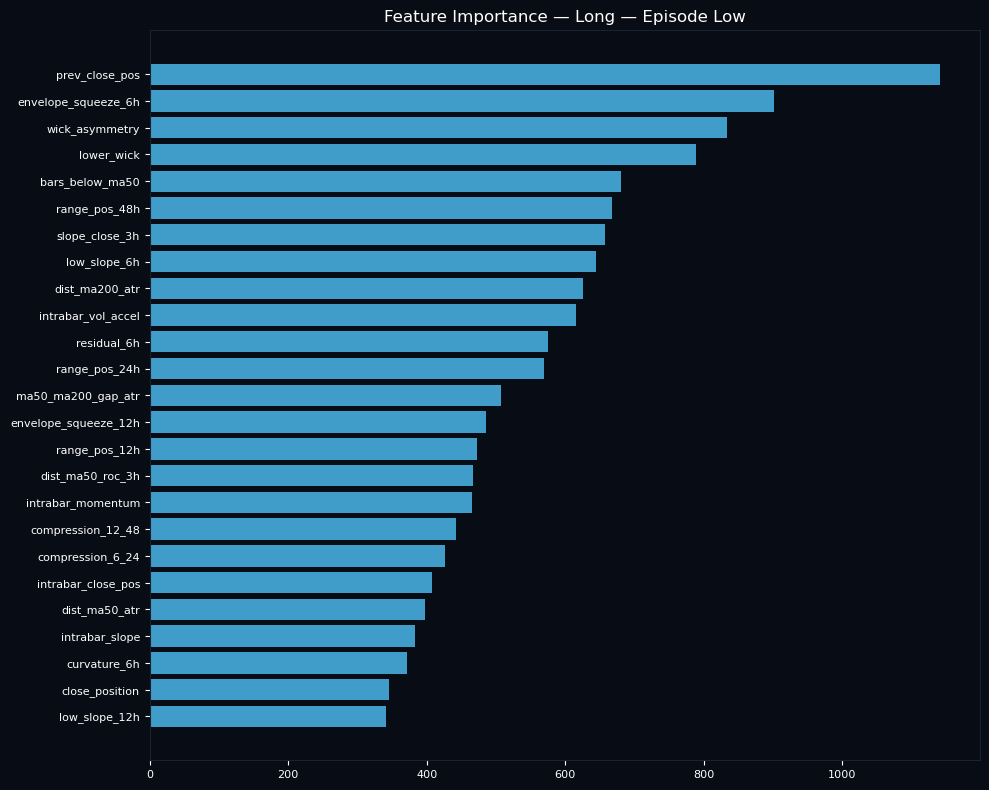

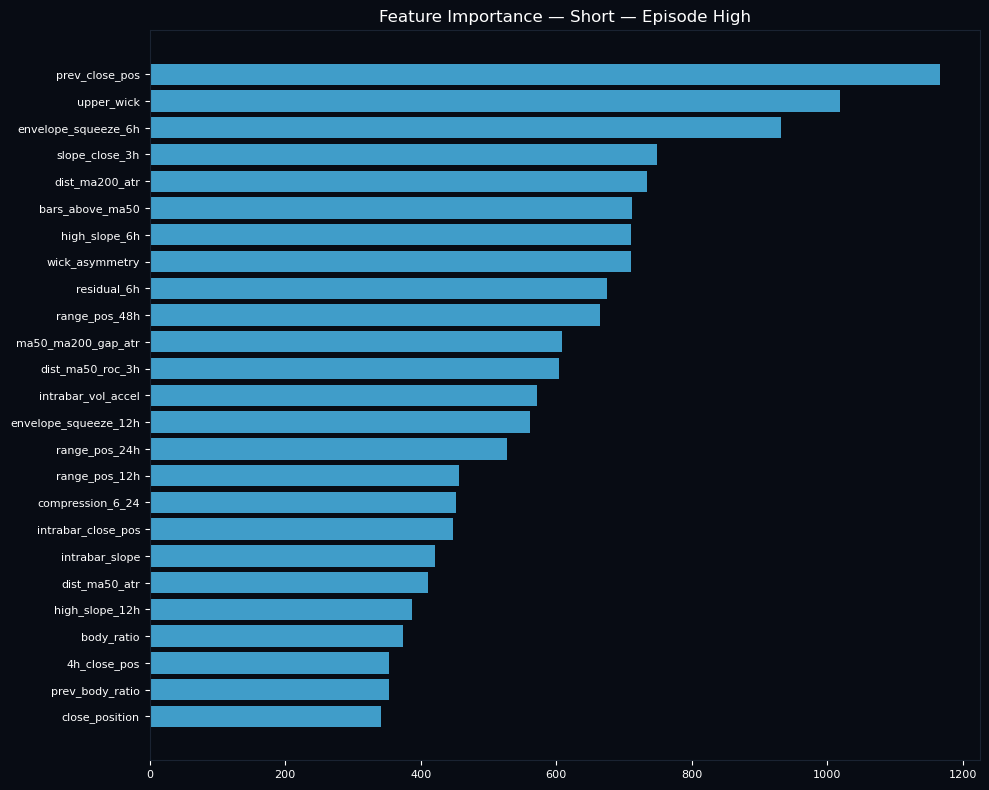

In [71]:
import matplotlib.pyplot as plt

for fname, label in [('model_ep_low.joblib', 'Long — Episode Low'), ('model_ep_high.joblib', 'Short — Episode High')]:
    bundle     = joblib.load(MODELS_DIR / fname)
    importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(25)
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#080c14'); ax.set_facecolor('#080c14')
    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_title(f'Feature Importance — {label}', color='white', fontsize=12)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    plt.tight_layout(); plt.show()


## 6. EV Simulation

For bars flagged as episode low (proba >= threshold): enter long at close, TP = first bar where price crosses above both MAs, timeout = close at T+120H, spread = 1.5p.

In [72]:
def ev_sim(results, direction):
    SPREAD_PIPS = 1.5
    sign = 1 if direction == 'long' else -1
    print(f'EV simulation ({direction.upper()}): TP=first close {"above" if direction=="long" else "below"} both MAs, timeout=T+120H')
    print(f'{"Thresh":>8} {"N":>7} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8} {"Sharpe":>8}')
    print('-' * 65)
    for t in [0.05, 0.1, 0.2, 0.3, 0.5]:
        mask = results['proba'] >= t
        if mask.sum() < 10: continue
        sigs = results[mask]
        pnls = []
        for pair in PAIRS:
            pip  = PIP_SIZE[pair]
            ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
            ohlc.index = pd.to_datetime(ohlc.index)
            c_arr   = ohlc['close'].values
            ma50_s  = pd.Series(c_arr).rolling(50).mean()
            ma200_s = pd.Series(c_arr).rolling(200).mean()
            filt = sigs[sigs['pair'] == pair]
            for ts, row in filt.iterrows():
                if ts not in ohlc.index: continue
                iloc  = ohlc.index.get_loc(ts)
                entry = ohlc['close'].iloc[iloc]
                pnl   = None
                for k in range(1, 121):
                    if iloc + k >= len(ohlc): break
                    c_k     = ohlc['close'].iloc[iloc+k]
                    ma50_k  = ma50_s.iloc[iloc+k]
                    ma200_k = ma200_s.iloc[iloc+k]
                    if pd.notna(ma50_k) and pd.notna(ma200_k):
                        if direction == 'long'  and c_k > ma50_k and c_k > ma200_k:
                            pnl = (c_k - entry) / pip - SPREAD_PIPS; break
                        elif direction == 'short' and c_k < ma50_k and c_k < ma200_k:
                            pnl = (entry - c_k) / pip - SPREAD_PIPS; break
                if pnl is None:
                    c_end = ohlc['close'].iloc[min(iloc+120, len(ohlc)-1)]
                    pnl   = sign * (c_end - entry) / pip - SPREAD_PIPS
                pnls.append(pnl)
        pnls   = np.array(pnls)
        wins   = pnls[pnls > 0]; losses = pnls[pnls <= 0]
        ev     = pnls.mean()
        sharpe = ev / pnls.std() * np.sqrt(252) if pnls.std() > 0 else 0
        print(f'{t:>8.2f} {len(pnls):>7,} {(pnls>0).mean():>7.1%} '
              f'{wins.mean() if len(wins) else 0:>9.1f} '
              f'{losses.mean() if len(losses) else 0:>9.1f} '
              f'{ev:>8.2f} {sharpe:>8.3f}')

ev_sim(results_long,  'long')
print()
ev_sim(results_short, 'short')


EV simulation (LONG): TP=first close above both MAs, timeout=T+120H
  Thresh       N      WR   Avg win  Avg loss       EV   Sharpe
-----------------------------------------------------------------
    0.05  22,072   69.9%      60.6    -123.4     5.19    0.624
    0.10  19,157   70.0%      61.0    -121.5     6.27    0.760
    0.20  16,159   70.6%      61.1    -120.2     7.77    0.942
    0.30  13,906   70.9%      60.9    -118.9     8.68    1.053
    0.50  10,016   72.0%      59.7    -119.5     9.48    1.123

EV simulation (SHORT): TP=first close below both MAs, timeout=T+120H
  Thresh       N      WR   Avg win  Avg loss       EV   Sharpe
-----------------------------------------------------------------
    0.05  27,685   69.9%      91.7    -108.8    31.46    2.365
    0.10  23,957   70.1%      90.1    -109.8    30.39    2.318
    0.20  19,894   70.4%      87.9    -110.1    29.38    2.321
    0.30  16,784   70.7%      86.6    -110.8    28.74    2.256
    0.50  11,413   71.4%      80.6   

## 7. Hour Distribution

In [73]:
for results, label in [(results_long, 'LONG'), (results_short, 'SHORT')]:
    sub = results[results['proba'] >= 0.2].copy()
    sub['hour'] = sub.index.hour
    by_hour = sub.groupby('hour').agg(n=('actual','count'), hit_rate=('actual','mean'))
    total = by_hour['n'].sum()
    print(f'Hour distribution ({label}, proba>=0.2), total={int(total):,}')
    print(f'{"Hour":>5} {"N":>6} {"%":>6} {"Hit%":>7}')
    print('-'*30)
    for hour, row in by_hour.iterrows():
        bar = '#' * int(row['n'] / total * 30)
        print(f'{hour:>5} {int(row["n"]):>6} {row["n"]/total:>6.1%} {row["hit_rate"]:>7.1%}  {bar}')
    print()


Hour distribution (LONG, proba>=0.2), total=16,159
 Hour      N      %    Hit%
------------------------------
    0    655   4.1%    4.3%  #
    1    612   3.8%    7.7%  #
    2    493   3.1%    6.7%  
    3    533   3.3%    4.7%  
    4    560   3.5%    4.3%  #
    5    537   3.3%    4.3%  
    6    565   3.5%    7.8%  #
    7    693   4.3%    9.5%  #
    8    738   4.6%    6.1%  #
    9    704   4.4%    4.8%  #
   10    706   4.4%    4.2%  #
   11    594   3.7%    6.6%  #
   12    712   4.4%    9.8%  #
   13    855   5.3%    7.3%  #
   14    931   5.8%    7.1%  #
   15    929   5.7%    6.2%  #
   16    841   5.2%    5.0%  #
   17    668   4.1%    4.0%  #
   18    614   3.8%    5.9%  #
   19    526   3.3%    3.2%  
   20    627   3.9%   15.3%  #
   21    909   5.6%   23.7%  #
   22    652   4.0%   11.0%  #
   23    505   3.1%    5.5%  

Hour distribution (SHORT, proba>=0.2), total=19,894
 Hour      N      %    Hit%
------------------------------
    0    905   4.5%    7.3%  #
    1   

## 8. Per-Pair Breakdown

In [74]:
for results, label in [(results_long, 'LONG'), (results_short, 'SHORT')]:
    sub = results[results['proba'] >= 0.2]
    print(f'{label} per-pair (proba>=0.2):')
    print(f'{"Pair":>10} {"N":>6} {"Hit%":>7} {"AUC":>8}')
    print('-'*35)
    for pair, g in sub.groupby('pair'):
        if len(g) < 20 or g['actual'].nunique() < 2: continue
        print(f'{pair:>10} {len(g):>6,} {g["actual"].mean():>7.1%} {roc_auc_score(g["actual"], g["proba"]):>8.4f}')
    print()


LONG per-pair (proba>=0.2):
      Pair      N    Hit%      AUC
-----------------------------------
    AUDJPY  1,042    8.5%   0.8370
    AUDNZD  1,074    8.5%   0.8944
    AUDUSD  1,161    7.5%   0.8000
    CADJPY  1,096    8.0%   0.8239
    CHFJPY  1,007    8.5%   0.7940
    EURAUD  1,035    7.1%   0.8401
    EURGBP  1,126    9.3%   0.8444
    EURJPY    986    8.2%   0.7777
    EURUSD  1,008    7.0%   0.7636
    GBPJPY    957    7.7%   0.7702
    GBPUSD    959    6.8%   0.7494
    NZDUSD  1,283    6.2%   0.8364
    USDCAD  1,016    7.1%   0.8240
    USDCHF  1,335    6.3%   0.7516
    USDJPY  1,074    7.4%   0.7625

SHORT per-pair (proba>=0.2):
      Pair      N    Hit%      AUC
-----------------------------------
    AUDJPY  1,520    6.2%   0.7784
    AUDNZD  1,638    6.5%   0.7832
    AUDUSD  1,201    6.6%   0.7464
    CADJPY  1,327    7.3%   0.7295
    CHFJPY  1,619    5.7%   0.7219
    EURAUD  1,271    6.1%   0.7879
    EURGBP  1,352    7.7%   0.7615
    EURJPY  1,404    6.0%   0.

## 9. Entry Quality — How Close to Actual Low/High?

In [75]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()
    early, late, bars_diffs, slippages = 0, 0, [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close','high','low']]
        ohlc.index = pd.to_datetime(ohlc.index)
        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            entry_ts  = ep['proba'].idxmax()
            actual_ep = ep[ep['actual'] == 1]
            if len(actual_ep) == 0: continue
            actual_ts = actual_ep.index[0]
            if entry_ts not in ohlc.index or actual_ts not in ohlc.index: continue
            ep_price  = ohlc['close'].loc[entry_ts]
            act_price = ohlc['low'].loc[actual_ts] if direction == 'long' else ohlc['high'].loc[actual_ts]
            bars_diff = (entry_ts - actual_ts).total_seconds() / 3600
            slippage  = (ep_price - act_price) / pip if direction == 'long' else (act_price - ep_price) / pip
            bars_diffs.append(bars_diff); slippages.append(slippage)
            if bars_diff < 0: early += 1
            else: late += 1
    total = early + late
    print(f'{label} entry quality ({total} episodes):')
    print(f'  Entered before actual extreme: {early} ({early/total:.1%})')
    print(f'  Entered after  actual extreme: {late}  ({late/total:.1%})')
    print(f'  Bars diff  — mean={np.mean(bars_diffs):.1f}H  median={np.median(bars_diffs):.1f}H')
    print(f'  Slippage   — mean={np.mean(slippages):.1f}p   median={np.median(slippages):.1f}p')
    print()


LONG entry quality (786 episodes):
  Entered before actual extreme: 256 (32.6%)
  Entered after  actual extreme: 530  (67.4%)
  Bars diff  — mean=4.4H  median=0.0H
  Slippage   — mean=70.1p   median=35.7p

SHORT entry quality (780 episodes):
  Entered before actual extreme: 335 (42.9%)
  Entered after  actual extreme: 445  (57.1%)
  Bars diff  — mean=5.0H  median=0.0H
  Slippage   — mean=50.1p   median=34.1p



In [76]:
# Baseline: no model, just first bar of each short episode
baseline_pnls = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
    ohlc.index = pd.to_datetime(ohlc.index)
    c_arr   = ohlc['close'].values
    ma50_s  = pd.Series(c_arr).rolling(50).mean()
    ma200_s = pd.Series(c_arr).rolling(200).mean()
    both_above = (pd.Series(c_arr) > ma50_s) & (pd.Series(c_arr) > ma200_s)

    in_ep = False
    for i in range(len(c_arr)):
        if both_above.iloc[i] and not in_ep:
            in_ep = True
            entry = c_arr[i]
            pnl = None
            for k in range(1, 121):
                if i + k >= len(c_arr): break
                c_k = ohlc['close'].iloc[i+k]
                if pd.notna(ma50_s.iloc[i+k]) and c_k < ma50_s.iloc[i+k] and c_k < ma200_s.iloc[i+k]:
                    pnl = (entry - c_k) / pip - 1.5; break
            if pnl is None:
                pnl = (entry - c_arr[min(i+120, len(c_arr)-1)]) / pip - 1.5
            baseline_pnls.append(pnl)
        elif not both_above.iloc[i]:
            in_ep = False

baseline = np.array(baseline_pnls)
print(f'Baseline SHORT (no model, first bar of episode):')
print(f'N={len(baseline):,}  WR={(baseline>0).mean():.1%}  avg_win={baseline[baseline>0].mean():.1f}p  avg_loss={baseline[baseline<=0].mean():.1f}p  EV={baseline.mean():.2f}p')


Baseline SHORT (no model, first bar of episode):
N=39,791  WR=75.1%  avg_win=46.8p  avg_loss=-119.0p  EV=5.46p


In [77]:
# Deduped EV: one trade per episode (highest proba bar), both directions
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    pnls = []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
        ohlc.index = pd.to_datetime(ohlc.index)
        ma50_s  = pd.Series(ohlc['close'].values).rolling(50).mean()
        ma200_s = pd.Series(ohlc['close'].values).rolling(200).mean()

        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            ts    = ep['proba'].idxmax()
            if ts not in ohlc.index: continue
            iloc  = ohlc.index.get_loc(ts)
            entry = ohlc['close'].iloc[iloc]
            pnl   = None
            for k in range(1, 121):
                if iloc + k >= len(ohlc): break
                c_k = ohlc['close'].iloc[iloc+k]
                m50 = ma50_s.iloc[iloc+k]; m200 = ma200_s.iloc[iloc+k]
                if pd.notna(m50) and pd.notna(m200):
                    if direction == 'long'  and c_k > m50 and c_k > m200:
                        pnl = (c_k - entry) / pip - 1.5; break
                    elif direction == 'short' and c_k < m50 and c_k < m200:
                        pnl = (entry - c_k) / pip - 1.5; break
            if pnl is None:
                c_end = ohlc['close'].iloc[min(iloc+120, len(ohlc)-1)]
                pnl = ((c_end - entry) if direction == 'long' else (entry - c_end)) / pip - 1.5
            pnls.append(pnl)

    pnls = np.array(pnls)
    wins = pnls[pnls > 0]; losses = pnls[pnls <= 0]
    print(f'{label} deduped: N={len(pnls):,}  WR={(pnls>0).mean():.1%}  '
          f'avg_win={wins.mean():.1f}p  avg_loss={losses.mean():.1f}p  EV={pnls.mean():.2f}p')


LONG deduped: N=1,154  WR=78.2%  avg_win=87.7p  avg_loss=-116.8p  EV=43.08p
SHORT deduped: N=1,101  WR=75.4%  avg_win=68.5p  avg_loss=-103.6p  EV=26.12p


In [79]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    hold_times, never_hit = [], 0
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
        ohlc.index = pd.to_datetime(ohlc.index)
        c_arr   = ohlc['close'].values
        ma200_s = pd.Series(c_arr).rolling(200).mean()

        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            ts   = ep['proba'].idxmax()
            if ts not in ohlc.index: continue
            iloc = ohlc.index.get_loc(ts)
            entry = c_arr[iloc]
            hit_bar = None
            for k in range(1, len(c_arr) - iloc):
                c_k  = c_arr[iloc + k]
                m200 = ma200_s.iloc[iloc + k]
                if pd.isna(m200): continue
                if direction == 'long'  and c_k > m200:
                    hit_bar = k; break
                elif direction == 'short' and c_k < m200:
                    hit_bar = k; break
            if hit_bar is None:
                never_hit += 1; continue
            pnl = ((c_arr[iloc+hit_bar] - entry) if direction == 'long' else (entry - c_arr[iloc+hit_bar])) / pip - 1.5
            hold_times.append({'bars': hit_bar, 'pnl': pnl, 'win': pnl > 0})

    df_h = pd.DataFrame(hold_times)
    print(f'{label} hold period (N={len(df_h):,}, never_hit={never_hit}):')
    print(f'  Mean:   {df_h["bars"].mean():.1f}H')
    print(f'  Median: {df_h["bars"].median():.0f}H')
    print(f'  P25:    {df_h["bars"].quantile(0.25):.0f}H')
    print(f'  P75:    {df_h["bars"].quantile(0.75):.0f}H')
    print(f'  P90:    {df_h["bars"].quantile(0.90):.0f}H')
    print(f'  Max:    {df_h["bars"].max():.0f}H')
    print()
    print(f'  Winners  — mean={df_h[df_h["win"]]["bars"].mean():.1f}H  median={df_h[df_h["win"]]["bars"].median():.0f}H')
    print(f'  Losers   — mean={df_h[~df_h["win"]]["bars"].mean():.1f}H  median={df_h[~df_h["win"]]["bars"].median():.0f}H')
    print()
    print(f'  Buckets:')
    for lo, hi in [(1,12),(12,24),(24,48),(48,72),(72,120),(120,240),(240,99999)]:
        n = ((df_h['bars']>=lo)&(df_h['bars']<hi)).sum()
        print(f'    {lo:>4}-{hi:>4}H: {n:>5,} ({n/len(df_h):.1%})')
    print()


LONG hold period (N=1,147, never_hit=7):
  Mean:   59.4H
  Median: 20H
  P25:    3H
  P75:    86H
  P90:    183H
  Max:    506H

  Winners  — mean=29.3H  median=10H
  Losers   — mean=193.3H  median=185H

  Buckets:
       1-  12H:   489 (42.6%)
      12-  24H:   115 (10.0%)
      24-  48H:   133 (11.6%)
      48-  72H:    89 (7.8%)
      72- 120H:   124 (10.8%)
     120- 240H:   145 (12.6%)
     240-99999H:    52 (4.5%)

SHORT hold period (N=1,085, never_hit=16):
  Mean:   65.0H
  Median: 32H
  P25:    5H
  P75:    95H
  P90:    175H
  Max:    650H

  Winners  — mean=36.8H  median=20H
  Losers   — mean=181.5H  median=173H

  Buckets:
       1-  12H:   379 (34.9%)
      12-  24H:   106 (9.8%)
      24-  48H:   138 (12.7%)
      48-  72H:   101 (9.3%)
      72- 120H:   155 (14.3%)
     120- 240H:   161 (14.8%)
     240-99999H:    45 (4.1%)



In [80]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    print(f'{label} — timeout sensitivity:')
    print(f'{"Timeout":>10} {"N":>6} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8}')
    print('-'*55)

    for timeout in [24, 48, 72, 120, 240, 99999]:
        pnls = []
        for pair in PAIRS:
            pip  = PIP_SIZE[pair]
            ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
            ohlc.index = pd.to_datetime(ohlc.index)
            c_arr   = ohlc['close'].values
            ma200_s = pd.Series(c_arr).rolling(200).mean()

            pr = r2[r2['pair'] == pair]
            for ep_id, ep in pr.groupby('ep_id'):
                ts   = ep['proba'].idxmax()
                if ts not in ohlc.index: continue
                iloc  = ohlc.index.get_loc(ts)
                entry = c_arr[iloc]
                pnl   = None
                for k in range(1, min(timeout+1, len(c_arr)-iloc)):
                    c_k  = c_arr[iloc+k]
                    m200 = ma200_s.iloc[iloc+k]
                    if pd.isna(m200): continue
                    if direction == 'long'  and c_k > m200:
                        pnl = (c_k - entry) / pip - 1.5; break
                    elif direction == 'short' and c_k < m200:
                        pnl = (entry - c_k) / pip - 1.5; break
                if pnl is None:
                    c_end = c_arr[min(iloc+timeout, len(c_arr)-1)]
                    pnl = ((c_end - entry) if direction == 'long' else (entry - c_end)) / pip - 1.5
                pnls.append(pnl)

        pnls = np.array(pnls)
        wins = pnls[pnls > 0]; losses = pnls[pnls <= 0]
        lbl  = f'{timeout}H' if timeout < 99999 else 'none'
        print(f'{lbl:>10} {len(pnls):>6,} {(pnls>0).mean():>7.1%} '
              f'{wins.mean() if len(wins) else 0:>9.1f} '
              f'{losses.mean() if len(losses) else 0:>9.1f} '
              f'{pnls.mean():>8.2f}')
    print()


LONG — timeout sensitivity:
   Timeout      N      WR   Avg win  Avg loss       EV
-------------------------------------------------------
       24H  1,154   72.1%      76.2     -47.9    41.55
       48H  1,154   74.4%      80.9     -68.3    42.72
       72H  1,154   77.3%      81.4     -88.5    42.82
      120H  1,154   79.8%      80.8    -116.9    40.91
      240H  1,154   81.4%      80.1    -144.9    38.22
      none  1,154   81.5%      80.3    -165.6    34.74

SHORT — timeout sensitivity:
   Timeout      N      WR   Avg win  Avg loss       EV
-------------------------------------------------------
       24H  1,101   61.9%      37.6     -46.7     5.45
       48H  1,101   67.6%      47.2     -65.6    10.65
       72H  1,101   71.2%      53.8     -77.8    15.92
      120H  1,101   77.1%      61.1     -97.4    24.80
      240H  1,101   79.7%      65.7     -93.7    33.41
      none  1,101   79.8%      66.7     -93.2    34.44

